In [1]:
%matplotlib notebook

import numpy as np
from matplotlib import pyplot as plt

from mmkin import *
from scipy import optimize

In [2]:
ks = KineticsSeries('./buffer/buffer.yaml', prefix='./buffer')

Loading: 210413_buffer_2µM_MproWT.csv...
 ... excluded
Loading: 210430_buffer_160_80_and_40µM_MproWT.csv...
Loading: 210427_buffer_160_and_80µM_MproN214A.csv...
Loading: 210428_buffer_160_and_80µM_Q256A.csv...
Loading: 210430_buffer_160_80_and_40µM_MproS284A.csv...
Loading: 210507_buffer_20µM_MproWT_N_Q_S.csv...
 ... excluded


In [3]:
ss = np.array([320.0, 160.0, 80.0, 40.0, 20.0, 10.0, 5.0])
ps = np.array([0])
p = 0

n_p = len(ps)
n_s = len(ss)
print(n_p, n_s)

ks.fit_v0(regions=1024)

print(ks.all_conditions)

1 7
[(0, 320.0), (0, 160.0), (0, 80.0), (0, 40.0), (0, 20.0), (0, 10.0), (0, 5.0)]


<IPython.core.display.Javascript object>


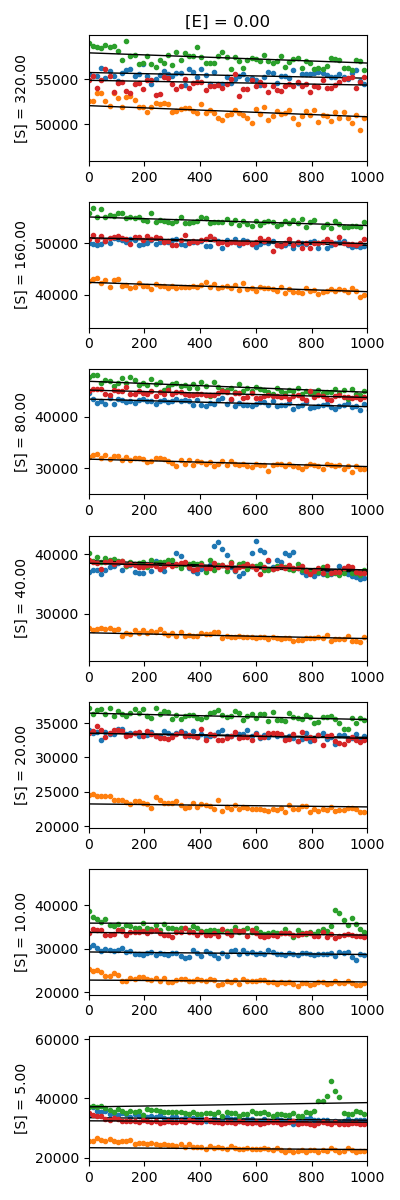

In [4]:
fig, axes = plt.subplots(n_s, 1, figsize=(4,12))


for i_s,s in enumerate(ss):

    v0_set = []

    for entry in ks.get(p, s):

        t = entry['dt'] * np.arange(len(entry['timeseries']))
        axes[i_s].plot(t, entry['timeseries'], '.')
        axes[i_s].plot(t, entry['v0'] * t + entry['b'], color='k', lw=1)

        axes[i_s].set_xlim([0, 1000])
        #axes[i_s].set_ylim([0, 45])

        if i_s == 0:
            axes[i_s].set_title('[E] = %.2f' % p)

        axes[i_s].set_ylabel('[S] = %.2f' % s)

plt.tight_layout()
plt.savefig('figures/buffer_traces.pdf')
plt.show()

<IPython.core.display.Javascript object>


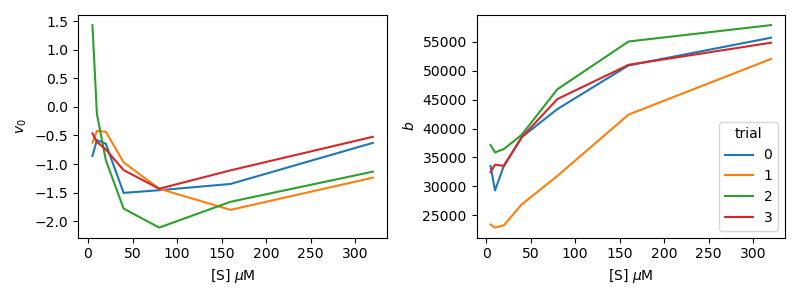

In [5]:
v0s = np.array([ [e['v0'] for e in ks.get(p, s)] for s in ss ])
bs  = np.array([ [e['b']  for e in ks.get(p, s)] for s in ss ])

# ---------------

fig = plt.figure(figsize=(8,3))

axL = plt.subplot(121)
axL.plot(ss, v0s)
axL.set_xlabel('[S] $\mu$M')
axL.set_ylabel('$v_0$')

axR = plt.subplot(122)
axR.plot(ss, bs)
axR.set_xlabel('[S] $\mu$M')
axR.set_ylabel('$b$')

plt.legend(range(v0s.shape[1]), title='trial')

plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


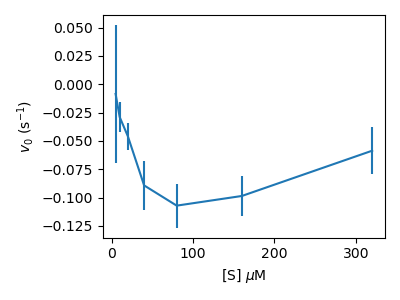

  320.0:	0.059
  160.0:	0.099
  80.0:	0.107
  40.0:	0.089
  20.0:	0.046
  10.0:	0.029
  5.0:	0.009


In [6]:
Y = v0s[:,:]

plt.figure(figsize=(4,3))
ax = plt.subplot(111)

ax.errorbar(ss, v0s[:,:].mean(1) / entry['dt'], yerr=v0s[:,:].std(1)/ entry['dt'])
ax.set_xlabel('[S] $\mu$M')
ax.set_ylabel('$v_0$ (s$^{-1}$)')

plt.tight_layout()
plt.show()

corrections = {}
for i,s in enumerate(ss):
    corrections[s] = - np.mean( v0s[i,:] ) / entry['dt']
    print('  %.1f:\t%.3f' % (s, corrections[s]))